In [1]:
from src import FaceAlignment, crop_csr, get_preds_fromhm, resize_video
import torch
import matplotlib.patches as patches
import torch.nn.functional as F
from torchvision.io import read_video, write_video
from matplotlib import pyplot as plt
from time import time

fa = FaceAlignment()

Loading pretrained model from c:\Users\Cevan\Documents\GitHub\face-alignment\src\detection\retina\weights\mobilenet0.25_Final.pth


In [2]:
vid = read_video('./TILTED.mp4', output_format="TCHW")[0][:4]#[(0, 90, 150, 200), :, :, :]
print(vid.shape)

c:\venv\TorchStandard\Lib\site-packages\torchvision\io\_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
c:\venv\TorchStandard\Lib\site-packages\torchvision\io\video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


torch.Size([4, 3, 720, 1280])


In [ ]:
cropped, landmarks, info = fa.sample_crop_csr(vid, batch_size=4)
cropped = cropped
# cropped_crop = cropped[:, :, 256:, 100:412]
info = info.cpu()

Crop-Sampling CSR: 100%|██████████| 1/1 [00:01<00:00,  1.48s/it]


In [8]:
submask = torch.zeros((vid.shape[0], 1, 512, 512), dtype=torch.bool)
submask[:, :, 256:, 100:412] = 1

In [9]:
res = fa.paste_back_csr(vid, cropped, info, submask=submask, batch_size=4)

Paste-Back CSR: 100%|██████████| 1/1 [00:00<00:00,  2.85it/s]


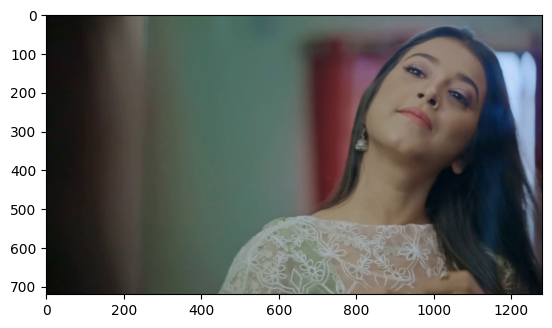

In [10]:
plt.imshow(res[0].permute(1, 2, 0).numpy()/255)

In [11]:
def pa2(cropped_frames, x1y1, sizes, rotations, original_shape, mask_mode=False):
    """
    Pastes cropped & rotated frames back into the original frame space.
    
    Args:
        cropped_frames: (N, 3, out_size, out_size)
        x1y1: (N, 2) - top-left corner of crop in original image (x1, y1)
        sizes: (N,) - width/height of the original square crop
        rotations: (N,) - rotation in radians (same as crop)
        original_shape: (H, W) - size of the full image
    
    Returns:
        tuple(
            pasted_frames: (N, 3, H, W) (pasted on black screen),
            mask: equivalent mask
        )
    """
    N, C, out_size, _ = cropped_frames.shape
    H, W = original_shape
    device = cropped_frames.device

    # Create normalized grid in the full image space
    grid_y, grid_x = torch.meshgrid(
        torch.linspace(0, H - 1, H, device=device),
        torch.linspace(0, W - 1, W, device=device),
        indexing='ij'
    )
    full_grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0).repeat(N, 1, 1, 1)  # (N, H, W, 2)

    # Convert full grid to crop-local coordinates
    # nx1, ny1 = x1.view(N, 1, 1), y1.view(N, 1, 1)
    size = sizes.view(N, 1, 1, 2)

    # Translate to crop-local (centered at crop)
    crop_coords = full_grid - x1y1.view(N, 1, 1, 2)  # (N, H, W, 2)

    # Normalize to [-1, 1] for grid_sample
    crop_coords = (crop_coords / size) * 2 - 1  # (N, H, W, 2)

    # Inverse rotation
    sin = torch.sin(-rotations).view(N, 1, 1)
    cos = torch.cos(-rotations).view(N, 1, 1)
    rot_matrix = torch.stack([
        torch.stack([cos, -sin], dim=-1),
        torch.stack([sin,  cos], dim=-1)
    ], dim=-2).squeeze(1)  # (N, 1, 2, 2)

    # Apply inverse rotation
    grid = crop_coords @ rot_matrix#.transpose(2, 3)  # (N, H, W, 2)

    # Map to [0, out_size-1] then normalize to [-1, 1]
    grid = (grid + 1) / 2  # [0,1]
    grid = grid * (out_size - 1)
    grid = (grid / (out_size - 1)) * 2 - 1  # normalize again for grid_sample

    # Sample from cropped_frames to reconstruct original frame
    if not mask_mode:
        pasted = torch.nn.functional.grid_sample(
            cropped_frames, grid, mode='bilinear', padding_mode='border', align_corners=True
        )
        return pasted
    else: #bool mask
        pasted = torch.nn.functional.grid_sample(
            cropped_frames, grid, mode='nearest', padding_mode='zeros', align_corners=True
        )
        return pasted.bool()

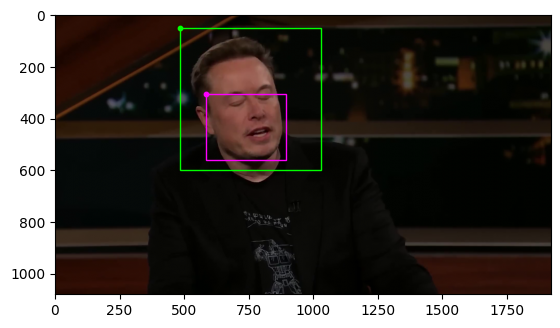

In [5]:
mask_infos = torch.Tensor([[100, 256, 312, 256], [100, 256, 312, 256], [100, 256, 312, 256], [100, 256, 312, 256]])
size_factor = mask_infos[:, 2] / 512 # torch.Size([4])
new_x1y1 = info[:, :2] + mask_infos[:, :2]# * size_factor.unsqueeze(1)
new_size = mask_infos[:, 2:] #* size_factor.unsqueeze(1)
new_infos = torch.cat([new_x1y1, new_size, info[:, 3].unsqueeze(1)], dim=1)

idx = 0
plt.imshow(vid[idx].permute(1, 2, 0).numpy()/255)
plt.scatter(info[idx, 0], info[idx, 1], s=10, c='lime', marker='o')
plt.scatter(new_x1y1[idx, 0], new_x1y1[idx, 1], s=10, c='magenta', marker='o')

rect = patches.Rectangle(new_x1y1[idx], new_size[idx, 0], new_size[idx, 1], linewidth=1, edgecolor='magenta', facecolor='none')
rect2 = patches.Rectangle(info[idx, :2], info[idx, 2], info[idx, 2], linewidth=1, edgecolor='lime', facecolor='none')
plt.gca().add_patch(rect)
plt.gca().add_patch(rect2)

In [ ]:
submask = torch.zeros((vid.shape[0], 1, 512, 512), dtype=torch.bool)
submask[:, :, 256:, 100:412] = 1
mask = pa2(
    submask.to(device="cpu", dtype=torch.float32),
    # new_infos[:, :2],
    # new_infos[:, :2],
    # new_infos[:, 2:4],
    info[:, :2],
    info[:, 2].repeat_interleave(2, 0),
    info[:, 3],
    (vid.shape[2], vid.shape[3]), mask_mode=True
)
pasteback = pa2(
    cropped_512.to(device="cpu", dtype=torch.float32),
    info[:, :2],
    info[:, 2].repeat_interleave(2, 0),
    info[:, 3],
    (vid.shape[2], vid.shape[3])
)
mask = mask.to(dtype=torch.bool, device="cpu")

idx = 0
frame = vid[idx]
frame_mask = mask[idx]
pasta = pasteback[idx].cpu()

composite = pasta * frame_mask + frame * (~ frame_mask)
plt.imshow(composite.permute(1, 2, 0).numpy()/255)

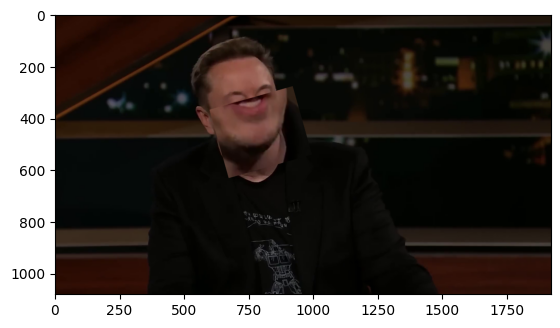

In [ ]:
submask = torch.zeros((vid.shape[0], 1, 512, 512), dtype=torch.bool)
submask[:, :, 256:, 100:412] = 1
mask = pa2(
    submask.to(device="cpu", dtype=torch.float32),
    # new_infos[:, :2],
    # new_infos[:, :2],
    # new_infos[:, 2:4],
    info[:, :2],
    info[:, 2].repeat_interleave(2, 0),
    info[:, 3],
    (vid.shape[2], vid.shape[3]), mask_mode=True
)
pasteback = pa2(
    cropped.to(device="cpu", dtype=torch.float32),
    info[:, :2],
    info[:, 2].repeat_interleave(2, 0),
    info[:, 3],
    (vid.shape[2], vid.shape[3])
)
mask = mask.to(dtype=torch.bool, device="cpu")


frame = vid[idx]
frame_mask = mask[idx]
pasta = pasteback[idx].cpu()

composite = pasta * frame_mask + frame * (~ frame_mask)
plt.imshow(composite.permute(1, 2, 0).numpy()/255)

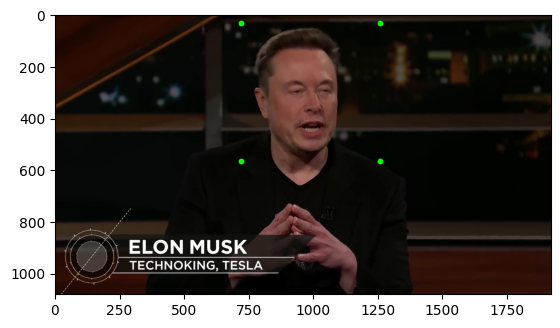

In [15]:
idx = 3
frame = vid[idx]
frame_mask = paste_mask[idx]
pasta = pasteback[idx].cpu()


def composite_over_original(pasted, original, binary_mask):
    feather = 5
    soft_mask = F.avg_pool2d(binary_mask.float(), kernel_size=feather*2+1, stride=1, padding=feather)
    soft_mask = soft_mask.clamp(0, 1)
    return pasted + original * (1 - soft_mask)

composite = pasta * frame_mask + frame * (~ frame_mask)
# composite = composite_over_original(pasta, frame, frame_mask)
plt.imshow(composite.permute(1, 2, 0).numpy()/255)


x1, y1 = info[idx, 0].item(), info[idx, 1].item()
s = info[idx, 2].item()
bl = (x1, y1)
br = (x1 + s, y1)
tl = (x1, y1 + s)
tr = (x1 + s, y1 + s)
pts = torch.Tensor([bl, br, tl, tr ])

# c = torch.Tensor((x1 + s / 2, y1 + s / 2)).unsqueeze(0)
# sca = torch.Tensor((1., 1.)).unsqueeze(0)
# ang = info[idx, 3:].cpu()
# rot = K.get_rotation_matrix2d(c, ang, sca)

# pts = pts @ rot
pts = pts.permute(1, 0)

plt.scatter(pts[0], pts[1], s=10, c='lime', marker='o')

In [25]:

def composite_over_original(pasted, original):
    # Assume: pasted and original are (N, 3, H, W)
    # mask = (pasted.abs().sum(dim=1, keepdim=True) > 1e-5).float()

    feather = 1
    binary_mask = (pasted.abs().sum(dim=1, keepdim=True) > 1e-5).float()
    soft_mask = F.avg_pool2d(binary_mask, kernel_size=feather*2+1, stride=1, padding=feather)
    soft_mask = soft_mask.clamp(0, 1)
    mask = soft_mask
    
    return pasted * mask + original * (1 - mask)
start = time()
comp = composite_over_original(pasteback, vid.to("cuda"))
print("Composite time:", time() - start)

Composite time: 0.01590442657470703


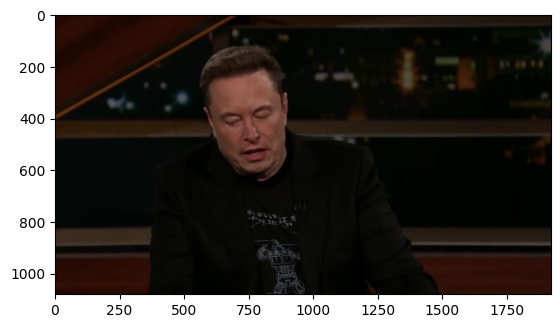

In [26]:
plt.imshow(comp[0].permute(1, 2, 0).cpu().numpy()/255)

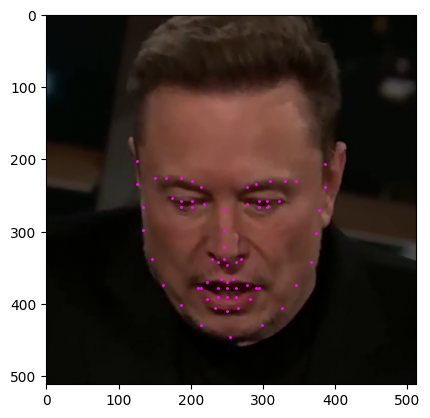

In [25]:
idx = 19
ldm = landmarks[idx].cpu().numpy()
plt.imshow(cropped[idx].permute(1, 2, 0).cpu().numpy()/255)
plt.scatter(ldm[:, 0], ldm[:, 1], s=5, c='magenta', marker='.')

In [ ]:
# write_video("musk_stab.mp4", cropped.cpu().permute(0, 2, 3, 1), fps=25)

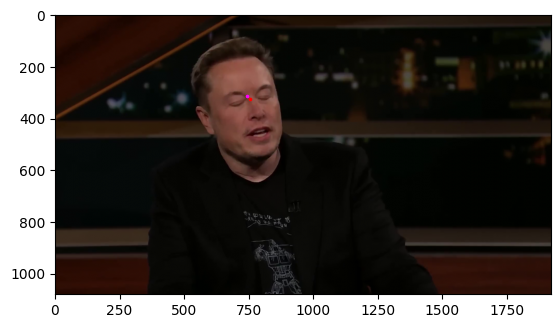

In [23]:
idx = 0

center = centers[idx].cpu().numpy()

le = eyes[idx, 0, :]
re = eyes[idx, 1, :]
diff = (re - le) / 2
ceye = le + diff
ceye = ceye.cpu().numpy() / resize_ratio

plt.imshow(vid[idx].permute(1, 2, 0).cpu().numpy()/255)
plt.scatter(center[0], center[1], s=10, c='magenta', marker='.')
plt.scatter(ceye[0], ceye[1], s=10, c='red', marker='.')
# plt.scatter(ceye[0], ceye[1], s=10, c='red', marker='.')